# Exercise 1: Linear and Logistic Regression with Error Estimation


## Instructions






### Setup check

Run the cell below before you begin. Every entry should report `found`.

In [527]:
import os
import sys

print("Python", sys.version.split()[0])

for package in ["numpy", "pandas", "matplotlib", "seaborn", "sklearn"]:
    try:
        __import__(package)
        print(f"{package:<12} found")
    except ImportError:
        print(f"{package:<12} MISSING  ->  pip install {package}")

for filename in ["headbrain.csv", "titanic.csv", "diabetes.csv"]:
    path = os.path.join("datasets", filename)
    status = "found" if os.path.isfile(path) else "MISSING"
    print(f"{filename:<16} {status}")

Python 3.12.13
numpy        found
pandas       found
matplotlib   found
seaborn      found
sklearn      found
headbrain.csv    found
titanic.csv      found
diabetes.csv     found


---
# Part A. Linear regression

## Program 1. Ordinary least squares regression, from first principles and with `scikit-learn`

### Aim

To implement simple linear regression in Python without a machine learning library, to reproduce
the same fit using `scikit-learn`, and to attach an uncertainty estimate to the fitted
coefficients.

### Theory

The regression line is written as $y = b_0 + b_1 x$. The least squares estimates of the two
coefficients are

$$
\newcommand{\vect}{\mathbf}
\begin{align}
b_1 &= \frac{\displaystyle \sum_{i=1}^{m}(x_i-\bar{x})(y_i-\bar{y})}{\displaystyle \sum_{i=1}^{m}(x_i-\bar{x})^2}
= \frac{(\vect{x}-\bar{x})^T(\vect{y}-\bar{y})}{(\vect{x}-\bar{x})^T(\vect{x}-\bar{x})}
\\
b_0 &= \bar{y}-b_1\bar{x}
\end{align}
$$

The quality of the fit is summarised by

$$
\begin{align}
\text{RMSE} &= \sqrt{\frac{1}{m}\sum_{i=1}^{m}(y_i-\hat{y_i})^2}
= \sqrt{\frac{(\vect{y}-\hat{\vect{y}})^T(\vect{y}-\hat{\vect{y}})}{m}}
\\
\text{SS}_{\text{tot}} &= \sum_{i=1}^{m}(y_i - \bar{y})^2 = (\vect{y}-\bar{y})^T(\vect{y}-\bar{y})
\\
\text{SS}_{\text{res}} &= \sum_{i=1}^{m}(y_i - \hat{y}_i)^2 = (\vect{y}-\hat{\vect{y}})^T(\vect{y}-\hat{\vect{y}})
\\
R^{2} &= 1-\frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}
\end{align}
$$

where $\vect{x} = (x_1,x_2,\dots,x_m)$ is the input vector, $\vect{y} = (y_1,y_2,\dots,y_m)$ is the
output vector, $\bar{x}$ and $\bar{y}$ are the corresponding means, and
$\hat{\vect{y}} = (\hat{y}_1,\hat{y}_2,\dots,\hat{y}_m)$ is the vector of predicted values.

Under the usual assumption of independent errors of constant variance, the standard errors of the
two coefficients follow from the residual variance
$s^2 = \text{SS}_{\text{res}}/(m-2)$:

$$
\begin{align}
\text{SE}(b_1) &= \sqrt{\frac{s^2}{\sum_{i=1}^{m}(x_i-\bar{x})^2}}
\\
\text{SE}(b_0) &= \sqrt{s^2\left[\frac{1}{m} + \frac{\bar{x}^2}{\sum_{i=1}^{m}(x_i-\bar{x})^2}\right]}
\end{align}
$$

The divisor $m-2$ appears because two parameters have already been estimated from the same data.

### TASK A1. Implementing the regression class

Complete the three methods of the class below. Use vectorised NumPy operations only, without an
explicit Python loop over the samples, and without importing `scikit-learn`.

In [528]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [529]:
class LinearRegression:
    """Simple linear regression by ordinary least squares."""

    def fit(self, X, y):
        """Estimate b0 and b1 from one-dimensional arrays X and y.

        Stores the results as self.b0 and self.b1 and returns self.
        """
        m = X.shape[0]

        # TODO
        # 1. compute the means of X and y
        X_mean = np.mean(X)
        y_mean = np.mean(y)

        # 2. compute the mean-centred vectors
        X_centered = X - X_mean
        y_centered = y - y_mean

        # 3. obtain b1 from the ratio of the two inner products given in the theory section
        b1 = np.sum(X_centered * y_centered) / np.sum(X_centered ** 2)

        # 4. obtain b0 from b1 and the two means
        b0 = y_mean - b1*X_mean

        # 5. store them as self.b0 and self.b1
        self.b0 = b0
        self.b1 = b1

        # 6. print the pair in the format
        print(f"(b0, b1) = ({self.b0:.3f}, {self.b1:.3f})")
        return self

        #raise NotImplementedError("Task A1: complete fit(), then delete this line")

    def predict(self, X):
        """Return the predicted response for the array X."""

        # TODO (1 mark)
        predicted_y = self.b0 + self.b1 * X
        return predicted_y

        #raise NotImplementedError("Task A1: complete predict(), then delete this line")

    def evaluate(self, X, y):
        """Print and return the RMSE and the R^2 score as a tuple."""

        y_pred = self.predict(X)

        # TODO
        # compute rmse, ss_tot, ss_res and r2 using the formulae above
        rmse = np.sqrt(np.mean((y - y_pred) ** 2))
        SS_tot = np.sum((y - np.mean(y)) ** 2)
        SS_res = np.sum((y - y_pred) ** 2)

        R_squared = 1 - (SS_res/SS_tot)


        # then print them as
        print("Root mean squared error:", round(rmse, 3))
        print("R^2 value:", round(R_squared, 3))

        #    and return the tuple (rmse, r2)
        return tuple([rmse, R_squared])

        #raise NotImplementedError("Task A1: complete evaluate(), then delete this line")

### TASK A2. Plotting the fit

Complete the plotting helper. The scatter of the observed data and the fitted straight line must
appear on the same axes.

def regression_plot(X, y, model, title=""):
    """Scatter plot of the data with the fitted regression line drawn over it."""
    plt.figure(figsize=(10, 6))
    plt.title(title)

    # TODO
    # 1. label the x axis as "Head size (cm^3)" and the y axis as "Brain weight (grams)"
    # 2. build a two-element array x_line spanning slightly beyond the data range,
    #    shaped as a column so that both implementations of predict() accept it
    # 3. evaluate the model on x_line to obtain y_line
    # 4. draw the observed points with plt.scatter and the fitted line with plt.plot
    # 5. add a legend and show the figure

    raise NotImplementedError("Task A2: complete regression_plot(), then delete this line")

In [530]:
def regression_plot(X, y, model, title = ""):
  plt.figure(figsize=(12,10))
  plt.title(title)
  plt.xlabel("Head size (cm^3)")
  plt.ylabel("Brain weight (grams)")
  x_line = np.array([X.min() - 1, X.max() + 1]).reshape(-1,1)
  y_line = model.predict(x_line)
  plt.scatter(X,y)
  plt.plot(x_line, y_line)
  plt.legend(["Fitted Line", "Observed points"])
  plt.show()


### TASK A3. Fitting the head and brain dataset

The dataset relates the head size of an adult to the mass of the brain. Load it, extract the two
columns of interest, fit the model, plot the result, and evaluate the fit.

In [531]:
# TODO : read datasets/headbrain.csv into a DataFrame named data,
# then print its shape and display the first five rows

data = pd.read_csv("./datasets/headbrain.csv")
print(data.shape)
data.head()

(237, 4)


,Gender,Age Range,Head Size(cm^3),Brain Weight(grams)
0,1,1,4512,1530
1,1,1,3738,1297
2,1,1,4261,1335
3,1,1,3777,1282
4,1,1,4177,1590


In [532]:
# TODO : extract the predictor and the response as one-dimensional NumPy arrays
X = data.loc[:,"Head Size(cm^3)"].to_numpy()   # column "Head Size(cm^3)"
y = data.loc[:,"Brain Weight(grams)"].to_numpy()   # column "Brain Weight(grams)"

(b0, b1) = (325.573, 0.263)


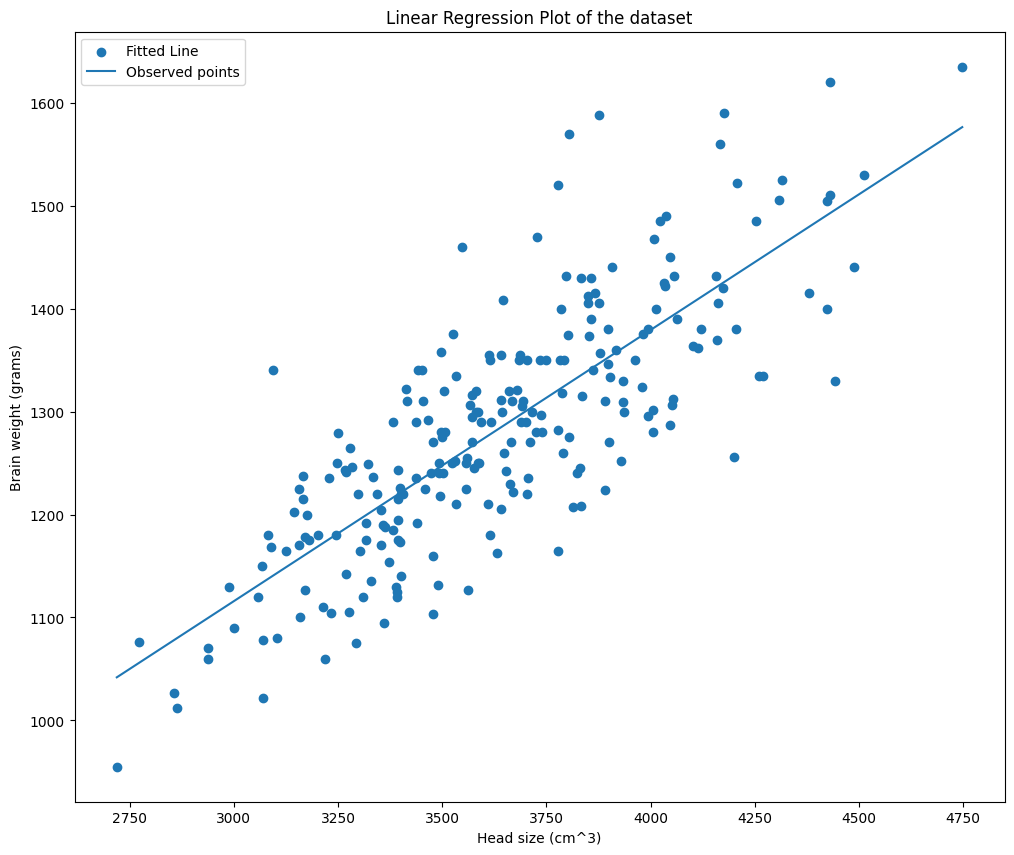

Root mean squared error: 72.121
R^2 value: 0.639


(np.float64(72.1206213783709), np.float64(0.639311719957))

In [533]:
# TODO : create the model, fit it, plot the fit, and evaluate it
model = LinearRegression()

model.fit(X,y)
regression_plot(X,y,model, "Linear Regression Plot of the dataset")
model.evaluate(X,y)

### TASK A4. Comparison with `scikit-learn`

Repeat the fit with the library estimator and confirm that the two implementations agree.

Note that `scikit-learn` expects a two-dimensional array of predictors, so the input has to be
reshaped from `(m,)` to `(m, 1)`.

In [534]:
from sklearn.linear_model import LinearRegression as SkLinearRegression
from sklearn.metrics import mean_squared_error

X1 = X.reshape(-1, 1)

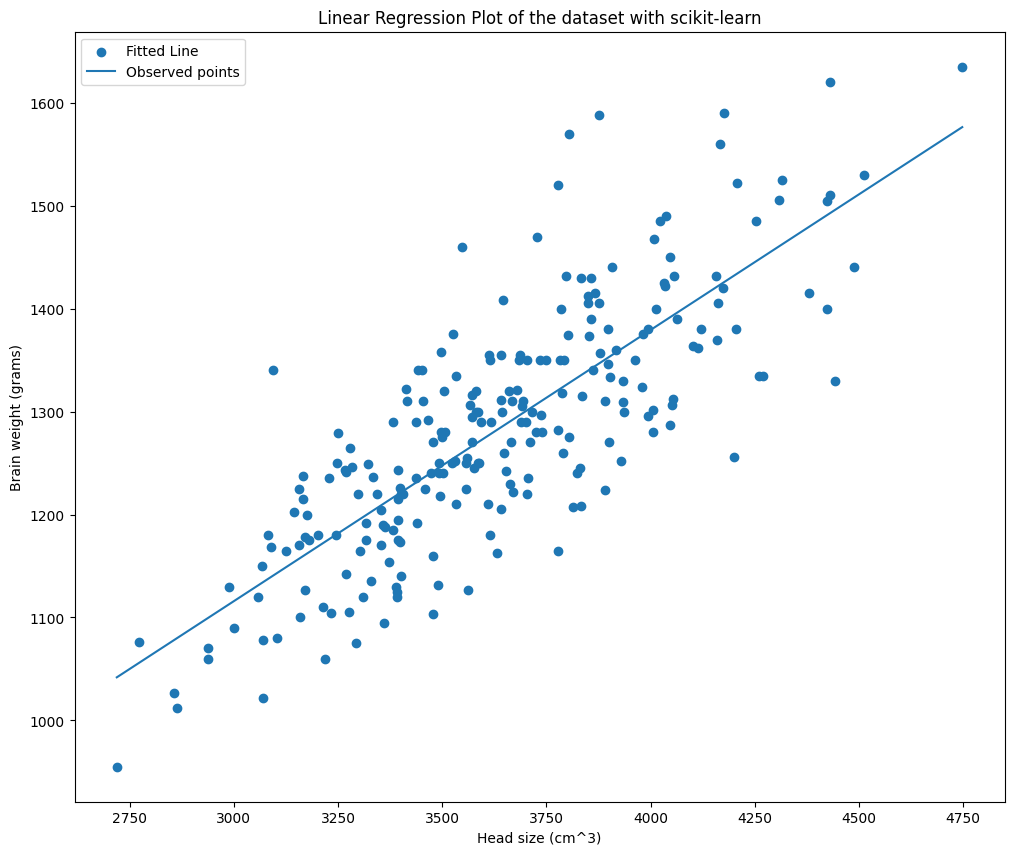

Intercept: 325.5734210494426
Coefficient: 0.26342933948939934
RMSE: 72.1206213783709
R^2 score: 0.639311719957
Absolute difference between my b0 and library values: 2.2737367544323206e-13
Absolute difference between my b1 and library values: 5.551115123125783e-17


In [535]:
# TODO
# 1. fit SkLinearRegression on X1 and y
sk_model = SkLinearRegression()
sk_model.fit(X1,y)

# 2. reuse regression_plot to display the fit
regression_plot(X, y, sk_model, "Linear Regression Plot of the dataset with scikit-learn")

# 3. print the intercept and the coefficient, the RMSE, and the R^2 score
print("Intercept:", sk_model.intercept_)
print("Coefficient:", sk_model.coef_[0])
print("RMSE:", np.sqrt(mean_squared_error(y, sk_model.predict(X1))))
print("R^2 score:", sk_model.score(X1, y))

# 4. print the absolute difference between your own b0, b1 and the library values
print("Absolute difference between my b0 and library values:", abs(model.b0 - sk_model.intercept_))
print("Absolute difference between my b1 and library values:", abs(model.b1 - sk_model.coef_[0]))


### TASK A5. Error estimation

A coefficient reported without an uncertainty is of limited scientific value. In this task the
uncertainty is estimated in two independent ways, first from the analytical expressions given in
the theory section and then by resampling.

The 95 per cent confidence interval of a coefficient is approximated as
$b \pm t_{0.975,\,m-2}\,\text{SE}(b)$, where the critical value is close to 1.96 for a sample of
this size.

In [536]:
def coefficient_standard_errors(X, y, model):
    # Return (se_b0, se_b1) for a fitted simple linear regression model.

    # TODO
    # 1. obtain the residuals y - model.predict(X)
    residuals = y - model.predict(X)

    # 2. compute the residual variance s^2 with the correct number of degrees of freedom
    s_squared = np.sum(residuals ** 2) / (X.shape[0] - 2)

    # 3. compute the two standard errors from the expressions in the theory section

    x_mean = np.mean(X)
    Sxx = np.sum((X - x_mean) ** 2)
    se_b1 = np.sqrt(s_squared / Sxx)
    se_b0 = np.sqrt(s_squared * (1 / X.shape[0] + x_mean**2 / Sxx))
    return se_b0, se_b1

    #raise NotImplementedError("Task A5: complete coefficient_standard_errors(), then delete this line")


# TODO: report b0 and b1 together with their standard errors and their 95 per cent
se_b0, se_b1 = coefficient_standard_errors(X, y, model)
print(f"b0 = {model.b0:.3f} +/- {1.96 * se_b0:.3f}")
print(f"b1 = {model.b1:.3f} +/- {1.96 * se_b1:.3f}")

# confidence intervals, in the form  b1 = 0.263 +/- 0.010

b0 = 325.573 +/- 92.396
b1 = 0.263 +/- 0.025


(b0, b1) = (378.726, 0.248)
(b0, b1) = (331.318, 0.263)
(b0, b1) = (280.077, 0.276)
(b0, b1) = (271.900, 0.277)
(b0, b1) = (337.163, 0.260)
(b0, b1) = (302.642, 0.270)
(b0, b1) = (279.532, 0.275)
(b0, b1) = (292.682, 0.273)
(b0, b1) = (379.985, 0.250)
(b0, b1) = (279.597, 0.277)
(b0, b1) = (397.224, 0.242)
(b0, b1) = (366.474, 0.251)
(b0, b1) = (295.008, 0.273)
(b0, b1) = (380.039, 0.248)
(b0, b1) = (341.499, 0.258)
(b0, b1) = (415.911, 0.242)
(b0, b1) = (341.483, 0.259)
(b0, b1) = (340.068, 0.261)
(b0, b1) = (315.099, 0.267)
(b0, b1) = (368.813, 0.251)
(b0, b1) = (342.090, 0.259)
(b0, b1) = (259.536, 0.280)
(b0, b1) = (355.545, 0.257)
(b0, b1) = (324.950, 0.263)
(b0, b1) = (315.215, 0.267)
(b0, b1) = (246.109, 0.284)
(b0, b1) = (285.787, 0.276)
(b0, b1) = (361.210, 0.254)
(b0, b1) = (357.297, 0.254)
(b0, b1) = (370.527, 0.251)
(b0, b1) = (291.618, 0.273)
(b0, b1) = (318.630, 0.264)
(b0, b1) = (336.631, 0.261)
(b0, b1) = (399.243, 0.242)
(b0, b1) = (394.947, 0.245)
(b0, b1) = (325.733,

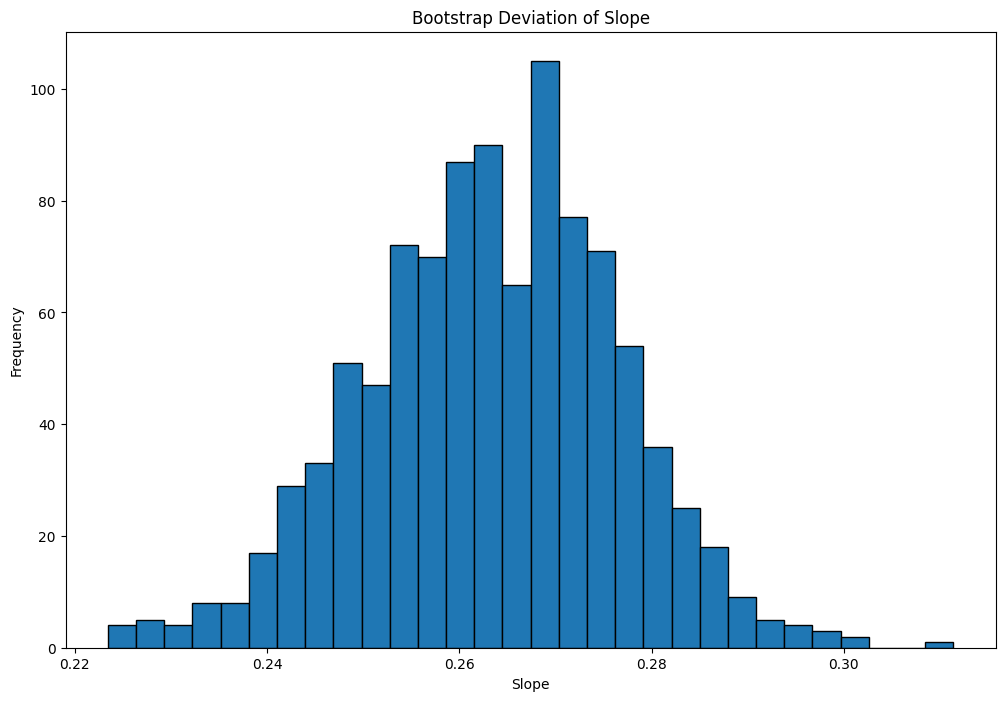

Bootstrap SE(b1) : 0.013154
Analytical_SE(b1) : 0.012907


In [537]:
def bootstrap_slope(X, y, n_resamples=1000, seed=0):
    # Return an array of slope estimates from n_resamples bootstrap replicates.
    rng = np.random.default_rng(seed)

    # TODO
    # 1. draw an index array of size m with replacement using rng.integers
    m = X.shape[0]

    # 2. fit the model to the resampled data and store the slope
    slopes = []
    for _ in range(n_resamples):
      idx = rng.integers(0, m, size=m)
      resamples = X[idx], y[idx]
      model = LinearRegression()
      model.fit(*resamples)

      slopes.append(model.b1)

    # 3. repeat n_resamples times and return the collected slopes
    return np.array(slopes)

    #raise NotImplementedError("Task A5: complete bootstrap_slope(), then delete this line")


# TODO: plot a histogram of the bootstrap slopes, print their standard deviation,
# and compare it with the analytical SE(b1) obtained above. Comment on the agreement.
slopes = bootstrap_slope (X, y)

plt.figure(figsize = (12,8))
plt.hist(slopes, bins = 30, edgecolor= "black")
plt.xlabel("Slope")
plt.ylabel("Frequency")
plt.title("Bootstrap Deviation of Slope")
plt.show()

bootstrap_se = np.std(slopes)
print(f"Bootstrap SE(b1) : {bootstrap_se:.6f}") #SD of bootstrap estimates is an estimate of SE
print(f"Analytical_SE(b1) : {se_b1:.6f}")

Comment : The bootstrap and analytical standard errors are nearly equal and close to 0.013, which shows this method uncertainity estimate of slope is reliable and close to the analytical formula.

### TASK A6. Written questions

Answer in the cell below.

1. The fitted slope carries physical units. State them and explain in one sentence what the slope
   means for this dataset.
2. The value of $R^2$ obtained here is well below unity. Give two distinct reasons why a single
   predictor cannot account for all of the variance in the response.
3. Suppose the head size were reported in cubic metres instead of cubic centimetres. State how
   $b_0$, $b_1$, RMSE, and $R^2$ would each change.

**ANSWER A6**

1. Unit of b1(slope) = grams/cm^3 , which means, on average, an increase of 1 cm^3 in head size is associated with an increase of b1 grams in predicted brain weight.

2. (1) Head size is not the only factor that affects brain weight. Other factors can also influence brain weight.
   
   (2) The relationship betweeen head size and brain weight is not perfectly linear, and the data contains natural measurement variability and measurement errors.

3. 1 m^3 = 10^6 cm^3
   
   x_new = x_old / 10^6
   
   The regression equation now becomes,
    
    y = b0 + b1 * (10^6 * x_new)
   
   Therefore,
   
   Intercept, b0 is unchnaged.
   
   Slope, b1 becomes 10^6 times larger.
   
   RMSE remains unchanged. (because y - y_pred is still the same)
   
   R^2 is unchanged. (Same reason as above)

---
# Part B. Logistic regression

## Program 1. Preprocessing and classification on the Titanic dataset with `scikit-learn`

### Aim

To prepare a dataset that contains missing values and categorical columns, and to fit and evaluate
a logistic regression classifier on it.

In [538]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

titanic_df = pd.read_csv("./datasets/titanic.csv")
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### TASK B1. Exploratory visualisation

The helper below draws a single titled figure. Use it to produce the six plots listed in the
comments.

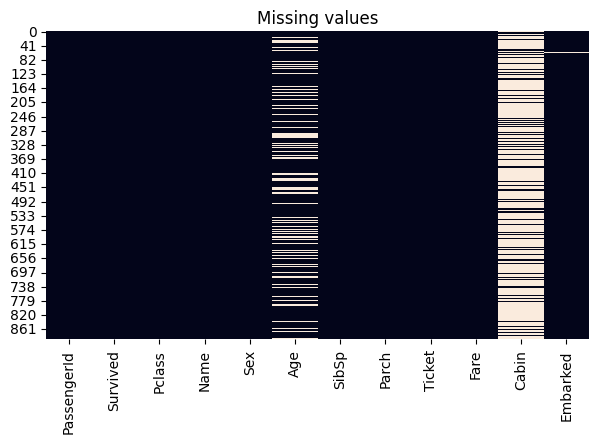

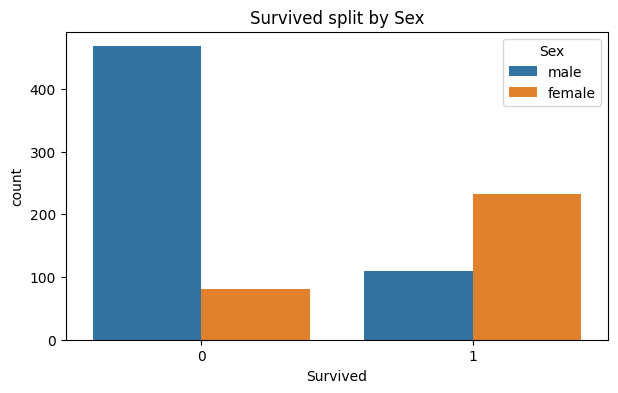

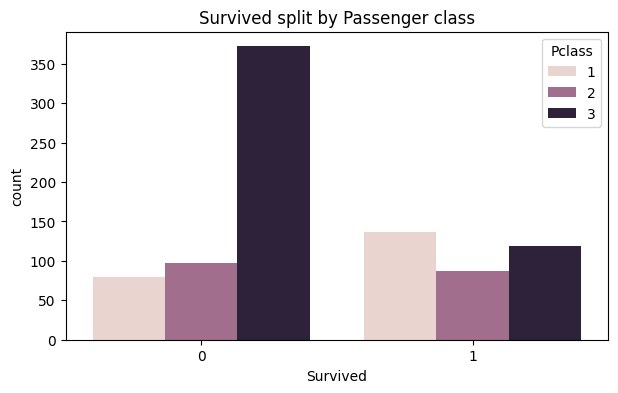

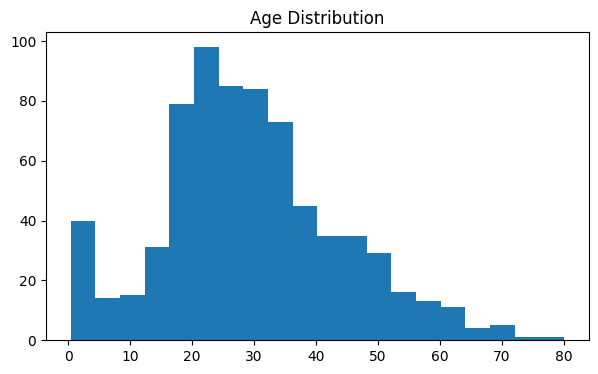

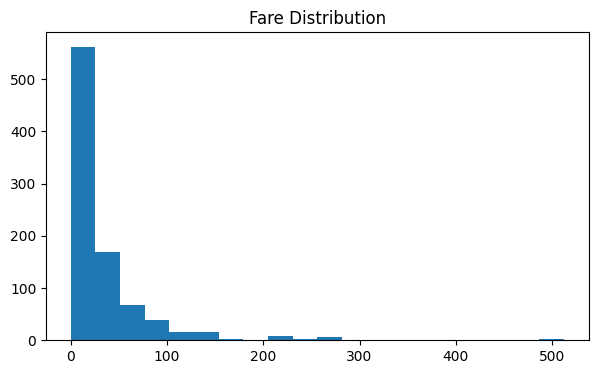

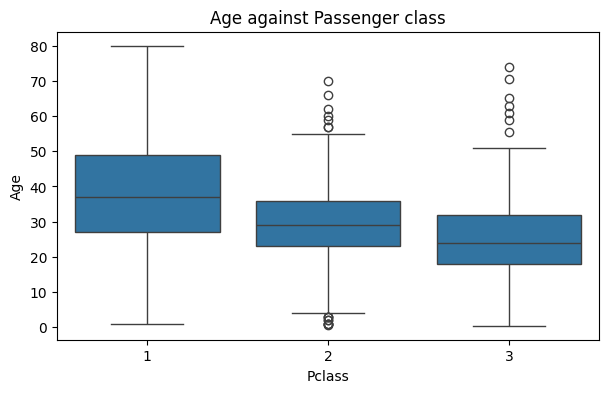

In [539]:
def plot(title, plot_func, *args, **kwargs):
    plt.figure(figsize=(7, 4))
    plt.title(title)
    plot_func(*args, **kwargs)
    plt.show()


# TODO : produce the following six figures using the helper above
# 1. a heatmap of titanic_df.isnull() to reveal which columns carry missing values
plot("Missing values", sns.heatmap, titanic_df.isnull(), cbar = False)

# 2. a count plot of Survived split by Sex
plot("Survived split by Sex", sns.countplot, data = titanic_df,x= "Survived", hue ="Sex")

# 3. a count plot of Survived split by Pclass
plot("Survived split by Passenger class", sns.countplot, titanic_df, x = "Survived", hue = "Pclass")

# 4. a histogram of Age, with the missing entries dropped
plot("Age Distribution", plt.hist, titanic_df["Age"].dropna(), bins = 20)

# 5. a histogram of Fare
plot("Fare Distribution", plt.hist, titanic_df["Fare"], bins = 20)

# 6. a box plot of Age against Pclass
plot("Age against Passenger class", sns.boxplot, data = titanic_df, x = "Pclass", y = "Age")

**ANSWER B1.** State which columns carry missing values, and describe in two or three sentences
what the box plot of age against passenger class reveals.

_The columns which have missing values are Age, Cabin, and Embarked._

_Pclass 1 : Highest median age(around 37 y/o),_

_Pclass 2 : Median age around 29 years,_

_Pclass 3 : Lowest median age ( around 24 y/o)._

_There are outliers, which means very old and young passengers are present in Pclass 2 and 3._

### TASK B2. Missing, categorical, and irrelevant columns

Missing ages are filled with the mean age of the passenger class rather than with the mean of the
whole column, because age and class are correlated. Complete the imputation, then encode the
categorical columns and remove the columns that carry no predictive value.

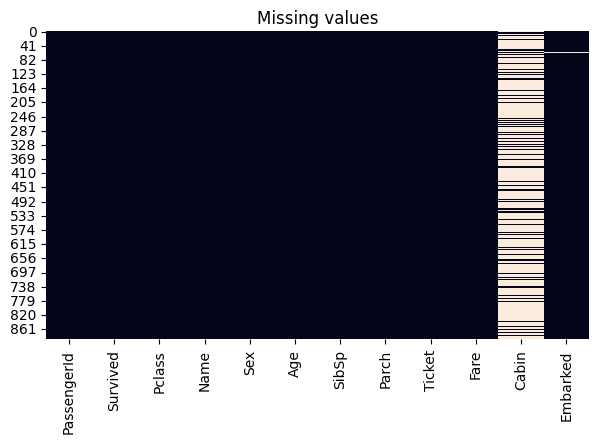

In [540]:
# TODO
# 1. build a dictionary mean_ages mapping each passenger class to the mean age within that class
# 2. complete impute_missing_age so that a missing age is replaced by the class mean
#    and an age that is already present is returned unchanged
# 3. apply it along axis 1 to the two columns Age and Pclass
# 4. redraw the missing value heatmap to confirm that the Age column is now complete

mean_ages = {
    1: titanic_df.loc[titanic_df["Pclass"] == 1, "Age"].mean(),
    2: titanic_df.loc[titanic_df["Pclass"] == 2, "Age"].mean(),
    3: titanic_df.loc[titanic_df["Pclass"] == 3, "Age"].mean()
}


def impute_missing_age(columns):
    age, Pclass = columns
    if pd.isnull(age):
        return mean_ages[Pclass]
    else:
        return age
    #raise NotImplementedError("Task B2: complete impute_missing_age(), then delete this line")


titanic_df["Age"] = titanic_df[["Age", "Pclass"]].apply(impute_missing_age, axis=1)
plot("Missing values", sns.heatmap, titanic_df.isnull(), cbar = False)

In [541]:
# TODO
# 1. drop the Cabin column, which is missing for most passengers, then drop the remaining
#    rows that still contain a missing value
titanic_df.drop(columns= ["Cabin"])
titanic_df.dropna()
# 2. one-hot encode Sex and Embarked with pd.get_dummies, passing drop_first=True,
#    and concatenate the result to the frame
titanic_df = pd.concat([titanic_df, pd.get_dummies(titanic_df[["Sex","Embarked"]], drop_first = True)], axis = 1)
# 3. drop Name, PassengerId, Ticket, Sex, and Embarked
titanic_df = titanic_df.drop(columns = ["Name", "PassengerId", "Ticket", "Sex", "Embarked"])
# 4. display the first five rows of the processed frame
titanic_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,NaN,True,False,True
1,1,1,38.0,1,0,71.2833,C85,False,False,False
2,1,3,26.0,0,0,7.9250,NaN,False,False,True
3,1,1,35.0,1,0,53.1000,C123,False,False,True
4,0,3,35.0,0,0,8.0500,NaN,True,False,True


**ANSWER B2.** Explain why `drop_first=True` is used when the categorical columns are encoded,
and what would go wrong if all of the indicator columns were retained.

_drop_first= True is used to remove one dummy column from each feature because it can be inferred from the other dummy columns. Keeping all the dummy variables would amke some features redundant and potenitally cause problems when training the regression model._

### TASK B3. Fitting and evaluating the classifier

Scale `Age` and `Fare` to the unit interval before fitting, so that the two columns of large
numerical range do not dominate the optimisation. Fix `random_state` in the split so that your
result is reproducible.

In [542]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import minmax_scale

# Ensure non-numeric columns are dropped if they weren't in previous steps
if 'Cabin' in titanic_df.columns:
    titanic_df = titanic_df.drop(columns=['Cabin'])
titanic_df = titanic_df.dropna()

# 1. rescale the Age and Fare columns with minmax_scale
titanic_df["Age"] = minmax_scale(titanic_df["Age"])
titanic_df["Fare"] = minmax_scale(titanic_df["Fare"])

# 2. separate the predictors X from the target y, which is the Survived column
x = titanic_df.drop(columns=["Survived"])
y = titanic_df["Survived"]

# 3. split into training and test sets with test_size=0.3 and a fixed random_state
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# 4. fit a LogisticRegression model and predict on the test set
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 5. print the classification report and the confusion matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.87      0.84       157
           1       0.79      0.73      0.76       111

    accuracy                           0.81       268
   macro avg       0.81      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268

[[136  21]
 [ 30  81]]


### TASK B4. Interpretation

Answer in the cell below.

1. Write out the confusion matrix you obtained and label the four entries as true positives, false
   positives, true negatives, and false negatives.
2. Define precision and recall in words, and compute both by hand for the survivor class from your
   confusion matrix. Confirm that your values match the classification report.
3. Rerun the split with three different values of `random_state` and record the accuracy each time.
   Comment on the spread and on what it implies about reporting a single accuracy figure.

**ANSWER B4**

1. _Confusion matrix :-_

    [[136  21]

    [ 30  81]]

    _So, here TN = 136, FP = 21, FN = 30, and TP = 80._
2. _Precision tells us how many passengers predicted as survivors actaully survived, while recall tells us how many of the actual survivors were correctly identified by the model. From the confusion matrix:-_

    _Precision = 81/(81 + 21) = 0.79_

    Recall = 81 / (81 + 30) = 0.73_

    _These values are the same as those shown in the classification report._

3. _The accuracy changes slightly when a different random_state is used because the training and testing data are split differently each time. This shows that a single accuracy value does not always represent the model's overall performacne. Using multiple train-test splits or cross-validation gives a mroe reliable estimate of how well the model performs._

---
## Program 2. Logistic regression by gradient descent, compared with `scikit-learn`

### Aim

To implement logistic regression through gradient descent on the log-likelihood, and to compare its
accuracy with the library implementation on the Pima diabetes dataset.

### Theory

$$
\newcommand{\vect}{\mathbf}
\text{Log-likelihood}, \quad LL = \sum_{i=1}^{m} y_i \log(p_i) + (1-y_i)\log(1-p_i)
$$

where

$$
p_i = p(\vect{x}_i, \vect{w}) = \frac{1}{1+e^{-\vect{w}^T\vect{x}_i}}
$$

Here $\vect{w} = (w_0, w_1, \dots, w_n)$ is the weight vector and
$\vect{x}_i = (1, x_{i1}, x_{i2}, \dots, x_{in})$ is the $i$th input vector, the leading unit
entry accounting for the intercept.

The weights are chosen so that

$$
\max_{\vect{w}} LL = \min_{\vect{w}} (-LL)
$$

The gradient of the negative log-likelihood takes the compact form

$$
\frac{d(-LL)}{d\vect{w}} = \sum_{i=1}^{m}(p_i-y_i)\,\vect{x}_i = (\vect{p}-\vect{y})^T X
$$

so that the update step of gradient descent is

$$
\vect{w} := \vect{w} - \alpha\,(\vect{p}-\vect{y})^T X
$$

where $\alpha$ is the learning rate.

### TASK B5. Implementing the classifier

Complete the class below. No optimisation routine from a library may be used.

In [543]:
import numpy as np
import pandas as pd

In [544]:
class LogitRegression:
    """Binary logistic regression trained by full batch gradient descent."""

    def __init__(self, learning_rate, iterations):
        self.learning_rate = learning_rate
        self.iterations = iterations

    def p(self, X):
        """Return the predicted probability for a design matrix that already carries
        the leading column of ones."""
        # TODO (1 mark): return the logistic function of X @ self.w
        return 1 / (1 + np.exp(-X @ self.w))

        #raise NotImplementedError("Task B5: complete p(), then delete this line")

    def fit(self, X, y):
        m, n = X.shape
        X = np.hstack([np.ones((m, 1)), X])
        y = y.squeeze()
        self.w = np.zeros(n + 1)

        # TODO (2 marks): repeat the update step self.iterations times,
        # then return self
        for _ in range(self.iterations):
          p = self.p(X)
          gradient = X.T @ (p - y) / m
          self.w -= self.learning_rate * gradient

        return self

        #raise NotImplementedError("Task B5: complete fit(), then delete this line")

    def predict(self, X):
        """Return the predicted class label, 0 or 1, for each row of X."""
        m = X.shape[0]
        X = np.hstack([np.ones((m, 1)), X])

        # TODO (1 mark): threshold the predicted probability at 0.5
        return (self.p(X) >= 0.5).astype(int)

        #raise NotImplementedError("Task B5: complete predict(), then delete this line")

In [545]:
from sklearn.preprocessing import minmax_scale
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

diabetes_df = pd.read_csv("./datasets/diabetes.csv")
X = minmax_scale(diabetes_df.iloc[:, :-1].values)
y = diabetes_df.iloc[:, -1:].values.reshape(-1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=6
)
print(X_train.shape, X_test.shape)

(512, 8) (256, 8)


In [546]:
def compute_accuracy(model, X_test, y_test):
    y_hat = model.predict(X_test)
    return (y_hat == y_test).mean() * 100


# TODO: fit both your own LogitRegression, with learning_rate=0.1 and iterations=1000,
# and the library LogisticRegression, then print the test accuracy of each
    for model in models:
      model.fit(X_train, y_train)
      accuracy = compute_accuracy(model, X_test, y_test)

      print(f"{type(model).__name__}: {accuracy:.2f}%")

models = [
    LogitRegression(learning_rate=0.1, iterations=1000),
    LogisticRegression(),
]


### TASK B6. Effect of the learning rate

Train your implementation with learning rates of 0.001, 0.01, 0.1, and 1.0, holding the number of
iterations fixed at 1000. Tabulate the test accuracy against the learning rate and comment in two
or three sentences on what you observe at the two extremes.

In [547]:
# TODO : loop over the four learning rates and report the test accuracy of each
learning_rates = [0.001, 0.01, 0.1, 1.0]
print("Learning Rate\tAccuracy")
for r in learning_rates:
  model = LogitRegression(learning_rate=r, iterations=1000)
  model.fit(X_train, y_train)

  accuracy = compute_accuracy(model, X_test, y_test)
  print(f"{r}\t\t{accuracy:.3f}%")

Learning Rate	Accuracy
0.001		67.578%
0.01		67.578%
0.1		74.219%
1.0		77.344%


**ANSWER B6.** _The smallest learning rates(0.001 and 0.01) gave the lowest accuracy because the model was learning too slowly. As the learning rate increased, the accuracy also improved, with 1.0 giving the best performance for this dataset. This suggests us that using an appropriate learning rate is important for training the model effectively._